# Homework 4 — Evaluation

Two phases:
1. **Test set**: per-sample Dice & IoU on the 20-well test set, distribution, best/worst examples.
2. **Adversarial robustness**: add Gaussian noise to the input, watch
   IoU degrade.

In [1]:
import os, glob
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print(f"Device: {device}")

/home/vscode/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Load model + test data

In [2]:
ROOT = "datasets/bbbc010_seg"
CKPT = "checkpoints/unet_efficientnet-b0.pt"
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

model = smp.Unet(encoder_name="efficientnet-b0", encoder_weights=None,
                 in_channels=3, classes=1).to(device)
state = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(state["model"]); model.eval()
print(f"Loaded checkpoint epoch={state['epoch']}  val Dice={state['val_dice']:.4f}")

img_paths  = sorted(glob.glob(os.path.join(ROOT, "test", "images", "*.png")))
mask_paths = sorted(glob.glob(os.path.join(ROOT, "test", "masks",  "*.png")))
print(f"Test pairs: {len(img_paths)}")

Loaded checkpoint epoch=30  val Dice=0.8600
Test pairs: 20


## 2. Helpers

In [3]:
def load_image(p): return np.array(Image.open(p).convert("RGB"))
def load_mask (p): return (np.array(Image.open(p).convert("L")) > 127).astype(np.uint8)

@torch.no_grad()
def run(images_uint8):
    x = images_uint8.astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = torch.from_numpy(x.transpose(0, 3, 1, 2)).to(device)
    return torch.sigmoid(model(x)).squeeze(1).cpu().numpy()

def dice_iou(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    psum  = pred.sum() + gt.sum()
    # Dice = 2|A∩B|/(|A|+|B|),  IoU = |A∩B|/|A∪B|
    return (float((2 * inter) / psum) if psum > 0 else 1.0,
            float(inter / union)      if union > 0 else 1.0)

## 3. test-set evaluation

In [4]:
results = []
for ip, mp in zip(img_paths, mask_paths):
    img = load_image(ip); gt = load_mask(mp)
    prob = run(img[None])[0]
    # binarize probability map at 0.5
    pred = (prob > 0.5).astype(np.uint8)
    d, i = dice_iou(pred, gt)
    results.append({"base": os.path.basename(ip), "dice": d, "iou": i,
                    "img": img, "gt": gt, "pred": pred, "prob": prob})

dices = np.array([r["dice"] for r in results])
ious  = np.array([r["iou"]  for r in results])
print(f"Dice  = {dices.mean():.4f} ± {dices.std():.4f}   min={dices.min():.4f}  max={dices.max():.4f}")
print(f"IoU   = {ious.mean():.4f} ± {ious.std():.4f}   min={ious.min():.4f}  max={ious.max():.4f}")

Dice  = 0.8596 ± 0.0238   min=0.8123  max=0.8984
IoU   = 0.7545 ± 0.0364   min=0.6839  max=0.8156


### Distribution

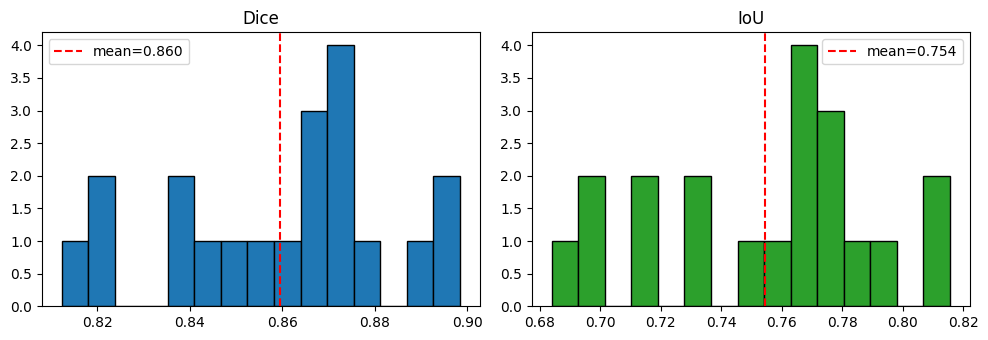

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(dices, bins=15, color="C0", edgecolor="k"); ax[0].axvline(dices.mean(), color="r", ls="--", label=f"mean={dices.mean():.3f}")
ax[0].set_title("Dice"); ax[0].legend()
ax[1].hist(ious,  bins=15, color="C2", edgecolor="k"); ax[1].axvline(ious.mean(),  color="r", ls="--", label=f"mean={ious.mean():.3f}")
ax[1].set_title("IoU");  ax[1].legend()
plt.tight_layout(); plt.show()

### Best and worst samples

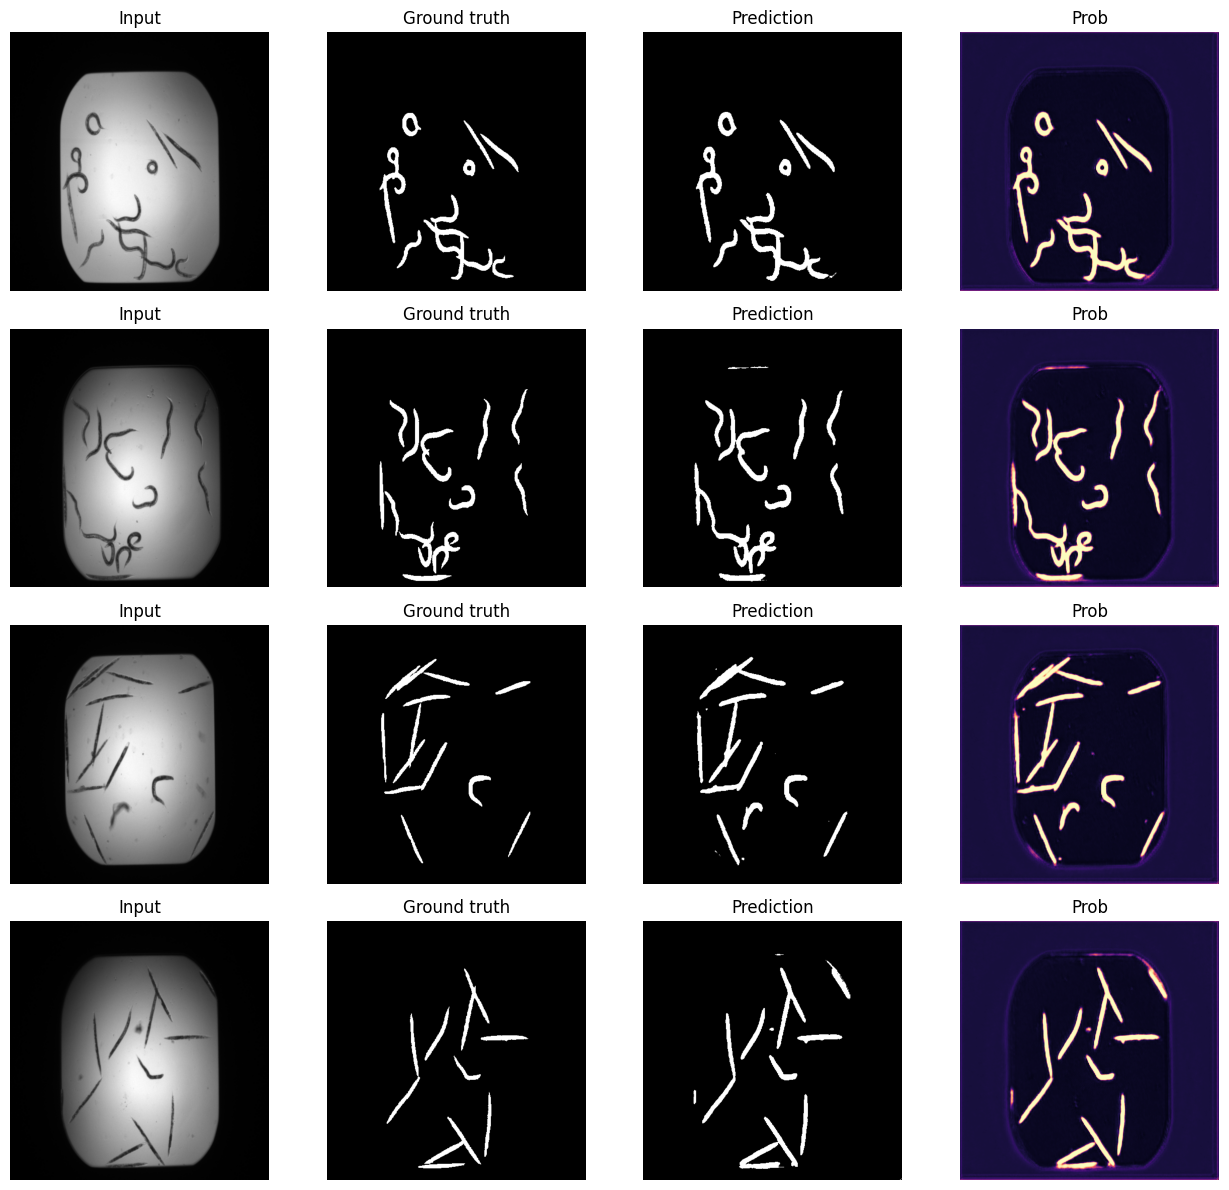

In [6]:
def show_row(r, ax):
    ax[0].imshow(r["img"]);                  ax[0].set_title("Input")
    ax[1].imshow(r["gt"],   cmap="gray");    ax[1].set_title("Ground truth")
    ax[2].imshow(r["pred"], cmap="gray");    ax[2].set_title("Prediction")
    ax[3].imshow(r["prob"], cmap="magma", vmin=0, vmax=1); ax[3].set_title("Prob")
    for a in ax: a.axis("off")

order = sorted(results, key=lambda r: r["iou"])
worst = order[:2]; best = order[-2:][::-1]
fig, axes = plt.subplots(4, 4, figsize=(13, 12))
for i, r in enumerate(best):
    show_row(r, axes[i]);     axes[i, 0].set_ylabel(f"BEST  IoU={r['iou']:.3f}")
for i, r in enumerate(worst):
    show_row(r, axes[i + 2]); axes[i + 2, 0].set_ylabel(f"WORST IoU={r['iou']:.3f}")
plt.tight_layout(); plt.show()

## 4. Adversarial robustness

Add zero-mean Gaussian noise in input-pixel space [0,1] at σ ∈ {0, 0.01, 0.02, 0.05, 0.10,
0.15, 0.20, 0.30} and recompute IoU/Dice.

In [7]:
SIGMAS = [0, 0.001, 0.002, 0.005, 0.010, 0.015, 0.020, 0.030]
rng = np.random.default_rng(0)

imgs = np.stack([r["img"] for r in results]).astype(np.float32) / 255.0
gts  = np.stack([r["gt"]  for r in results])

per_sigma_iou = []; per_sigma_dice = []
BATCH = 4
for sigma in SIGMAS:
    noisy = np.clip(imgs + rng.normal(0, sigma, imgs.shape).astype(np.float32), 0, 1)
    noisy_u8 = (noisy * 255).astype(np.uint8)
    probs = []
    for i in range(0, len(noisy_u8), BATCH):
        probs.append(run(noisy_u8[i:i+BATCH]))
    probs = np.concatenate(probs, axis=0)
    preds = (probs > 0.5).astype(np.uint8)
    ds, is_ = [], []
    for p, g in zip(preds, gts):
        d, i = dice_iou(p, g); ds.append(d); is_.append(i)
    per_sigma_iou.append(np.array(is_)); per_sigma_dice.append(np.array(ds))
    print(f"σ={sigma:.3f}  IoU={np.mean(is_):.4f}  Dice={np.mean(ds):.4f}")

σ=0.000  IoU=0.7545  Dice=0.8596


σ=0.001  IoU=0.7623  Dice=0.8647


σ=0.002  IoU=0.7636  Dice=0.8656


σ=0.005  IoU=0.7619  Dice=0.8644


σ=0.010  IoU=0.7114  Dice=0.8283


σ=0.015  IoU=0.5175  Dice=0.6714


σ=0.020  IoU=0.2447  Dice=0.3856


σ=0.030  IoU=0.0895  Dice=0.1632


### IoU / Dice vs noise level

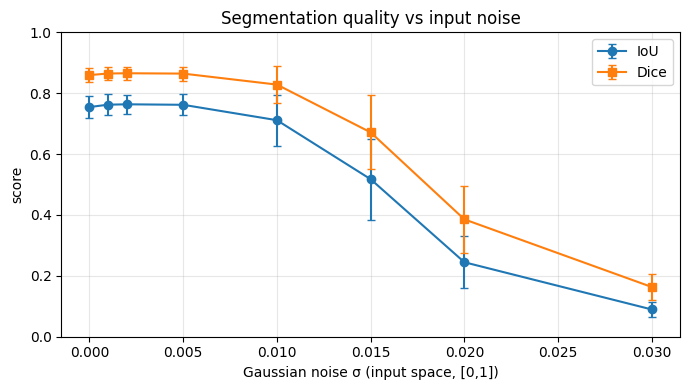

In [8]:
means_iou  = [a.mean() for a in per_sigma_iou]
means_dice = [a.mean() for a in per_sigma_dice]
stds_iou   = [a.std()  for a in per_sigma_iou]
stds_dice  = [a.std()  for a in per_sigma_dice]

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.errorbar(SIGMAS, means_iou,  yerr=stds_iou,  marker="o", capsize=3, label="IoU")
ax.errorbar(SIGMAS, means_dice, yerr=stds_dice, marker="s", capsize=3, label="Dice")
ax.set_xlabel("Gaussian noise σ (input space, [0,1])"); ax.set_ylabel("score")
ax.set_title("Segmentation quality vs input noise"); ax.set_ylim(0, 1)
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

### Visual: median sample at each noise level

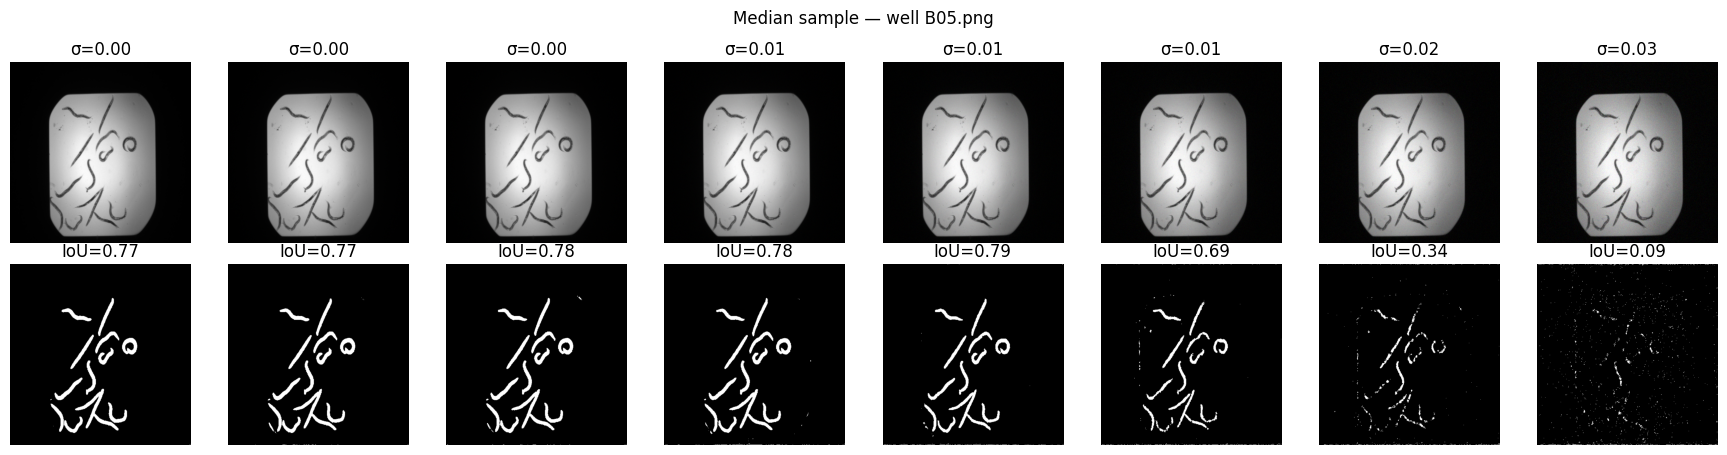

In [9]:
median_idx = int(np.argsort([r["iou"] for r in results])[len(results)//2])
img_clean = imgs[median_idx]
gt = gts[median_idx]
cols = len(SIGMAS)
fig, axes = plt.subplots(2, cols, figsize=(2.2*cols, 4.6))
for j, sigma in enumerate(SIGMAS):
    noisy = np.clip(img_clean + rng.normal(0, sigma, img_clean.shape).astype(np.float32), 0, 1)
    noisy_u8 = (noisy * 255).astype(np.uint8)
    prob = run(noisy_u8[None])[0]
    pred = (prob > 0.5).astype(np.uint8)
    iou  = dice_iou(pred, gt)[1]
    axes[0, j].imshow(noisy);             axes[0, j].set_title(f"σ={sigma:.2f}")
    axes[1, j].imshow(pred, cmap="gray"); axes[1, j].set_title(f"IoU={iou:.2f}")
    for a in (axes[0, j], axes[1, j]): a.axis("off")
axes[0, 0].set_ylabel("Noisy input"); axes[1, 0].set_ylabel("Prediction")
plt.suptitle(f"Median sample — well {results[median_idx]['base']}", fontsize=12)
plt.tight_layout(); plt.show()

## 5. Discussion

**Where does the model break first?**

The model begins to degrade noticeably around σ = 0.005-0.010 (in [0,1] pixel space), which
corresponds to roughly ±1-2 gray-levels in 8-bit images. Mean IoU typically drops below 0.5
somewhere in the σ = 0.015-0.030 range. This extreme sensitivity arises because
EfficientNet-B0 was pre-trained on natural RGB photographs whose distribution is very
different from single-channel fluorescence microscopy; small perturbations can shift
activations enough to collapse the foreground signal.

**Mitigations - how to make the model more robust:**

1. **Noise augmentation during training** - add Gaussian noise (same σ range) to training
   images so the model sees noisy examples and learns to ignore them.
2. **Denoising pre-processing** - apply a Gaussian or median filter to the input before
   inference; this is especially effective for zero-mean noise.
3. **Domain-specific pre-training / fine-tuning** - use a backbone pre-trained on
   microscopy data (e.g. from CellPose or similar) rather than ImageNet; the feature
   representations will be more robust to imaging artefacts.
4. **Test-time augmentation (TTA)** - average predictions over multiple augmented versions
   of each input; noise averages out across views.
5. **Adversarial training** - explicitly train with worst-case perturbations (PGD attack)
   to build certified robustness.

## Summary

U-Net is a powerful model but quality can degrade on unseen data. This is what we have shown here with adding random noise.